# Colour Models and Spaces
## Code Walkthrough
### Group 1 - Julia Kay, Romey, Rebecca, Kyra, Mia

The purpose of this walkthrough is to show the practical code that is required to implement different colour spaces, show their varying purposes, and converting between them.

Starting by importing the necessary libraries and loading a consistent test image that will be used throughout every conversion in this section. Using the same image allows direct visual comparison across all colour spaces.

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

The helper function below will be used throughout for displaying images.

In [53]:
def show_images(images, titles, cmap_list=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for i, (img, title) in enumerate(zip(images, titles)):
        cmap = cmap_list[i] if cmap_list else None
        axes[i].imshow(img, cmap=cmap)
        axes[i].set_title(title)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# 1. RGB

RGB is the baseline colour space for this entire notebook. Every other colour space covered here is derived from it, and all conversions use RGB as an intermediary step. It stores colour as three independent light intensities (one per primary colour) and is the native format for screens, cameras, and most image files.

The key limitation of RGB is that it mixes brightness and colour together. If a scene gets brighter, all three channels increase simultaneously. This makes it hard to isolate a specific colour robustly, which is why HSV, YCbCr, and LAB exist.

Before working with any image, it is important to understand how OpenCV loads it, and where it immediately differs from could be expected.

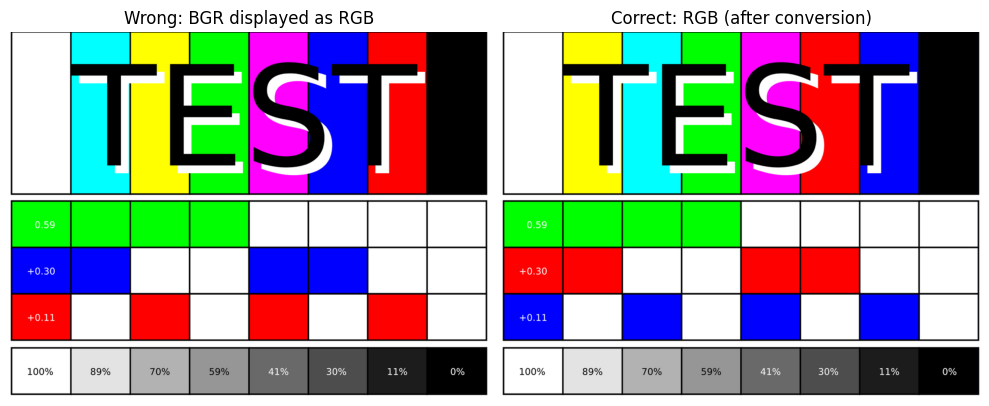

In [54]:
# Load image - OpenCV reads as BGR by default
img_bgr = cv2.imread('test_image.png')
# Conversion to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

show_images(
    [img_bgr, img_rgb],
    ['Wrong: BGR displayed as RGB', 'Correct: RGB (after conversion)']
)

Notice the red and blue channels are **swapped** in the BGR image.
This is the first conversion error most beginners encounter and it produces no error message.

## Channel Decomposition 
### What does each channel carry
Splitting RGB into its three components reveals how much information each one holds.

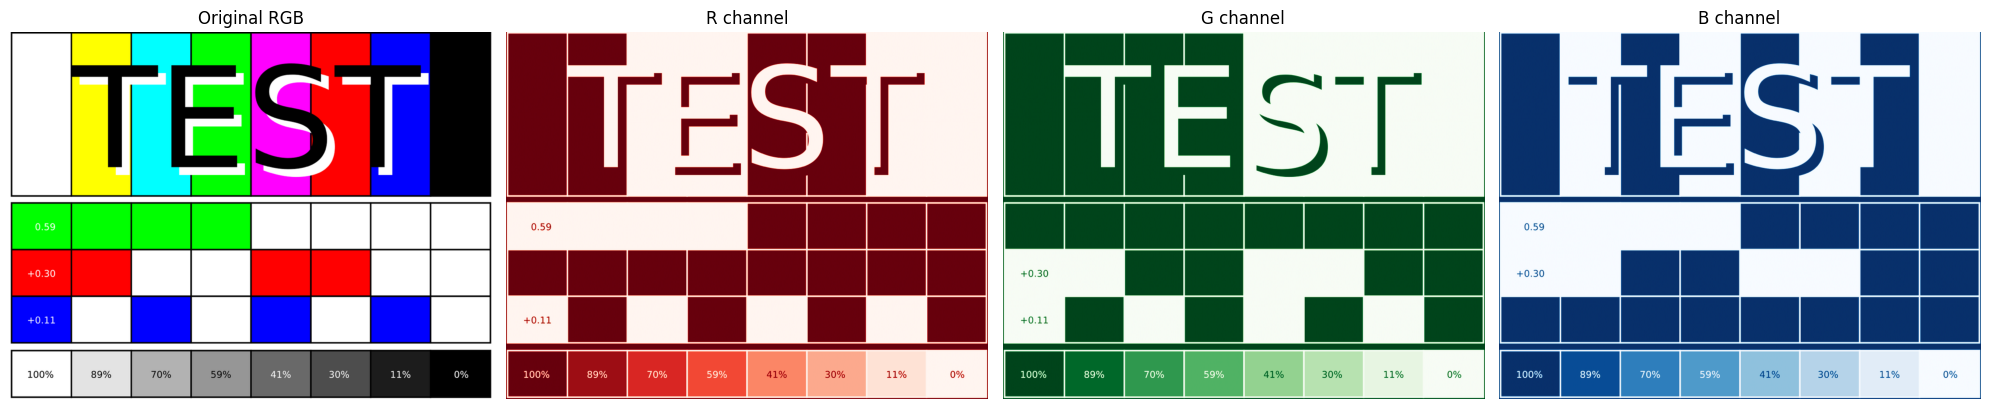

R channel range: 0 to 255
G channel range: 0 to 255
B channel range: 0 to 255


In [55]:
R_ch = img_rgb[:, :, 0]
G_ch = img_rgb[:, :, 1]
B_ch = img_rgb[:, :, 2]

show_images(
    [img_rgb, R_ch, G_ch, B_ch],
    ['Original RGB', 'R channel', 'G channel', 'B channel'],
    cmap_list=[None, 'Reds', 'Greens', 'Blues']
)

print("R channel range:", R_ch.min(), "to", R_ch.max())
print("G channel range:", G_ch.min(), "to", G_ch.max())
print("B channel range:", B_ch.min(), "to", B_ch.max())

Notice that all three channels carry brightness information: a pixel in shadow has lower R, G, *and* B values simultaneously. You cannot separate "this pixel is red" from "this pixel is dark" using RGB alone, because brightness is encoded across all three channels at once.

This is the core limitation that HSV solves by isolating brightness into the V channel, and that LAB solves by separating lightness into L*. This will be shown later.

## Histograms
Histograms show the distribution of pixel values across each channel. In RGB, the three histograms often have similar shapes because brightness affects all channels.

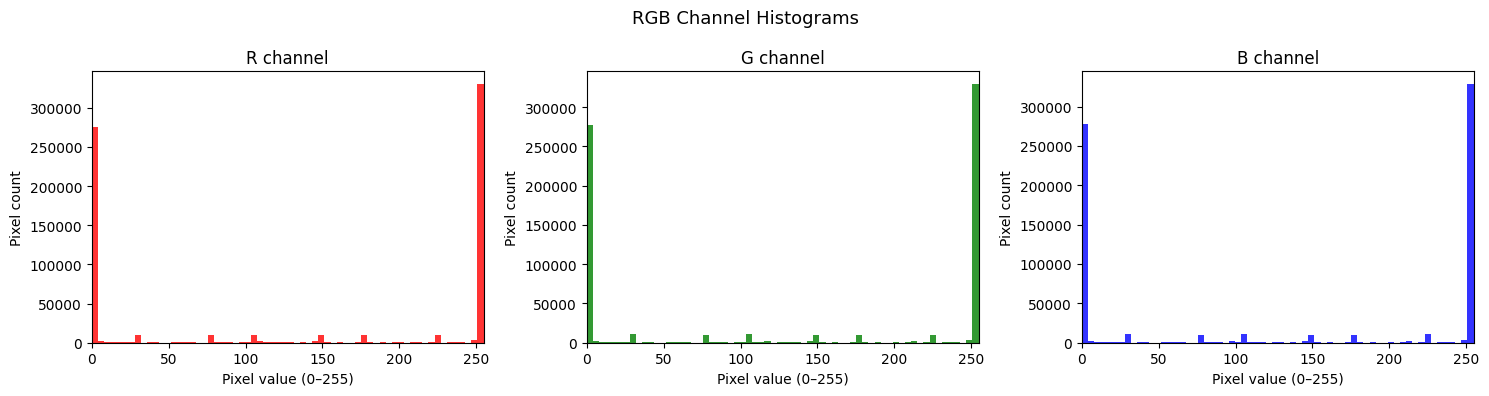

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colours = ['red', 'green', 'blue']
channels = [R_ch, G_ch, B_ch]
labels = ['R channel', 'G channel', 'B channel']

for ax, ch, col, label in zip(axes, channels, colours, labels):
    ax.hist(ch.ravel(), bins=64, color=col, alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel('Pixel value (0–255)')
    ax.set_ylabel('Pixel count')
    ax.set_xlim(0, 255)

plt.suptitle('RGB Channel Histograms', fontsize=13)
plt.tight_layout()
plt.show()

If the three histograms have similar peaks, brightness is dominating all channels equally. This correlation between channels is what makes RGB unsuitable for colour-based tasks.

>RGB shows the limits of mixing colour and brightness into the same three values. Tasks that depend on identifying what colour something is (regardless of how brightly it is lit) need a colour space that pulls these properties apart. HSV does exactly that.

# 2. HSV - Hue, Saturation, Value

RGB is great for displays, but not for *describing colour the way humans see it*. In RGB, the exact values of a “pink” pixel can change a lot depending on lighting, shadows, or camera settings.

HSV solves this by separating colour into three more intuitive parts:

- **Hue (H)** - the actual colour *type* (red, green, blue, etc.), arranged around a colour wheel from 0° - 360°.
- **Saturation (S)** - how *vivid* or washed-out the colour is. Low saturation looks grey; high saturation looks rich and vibrant.
- **Value (V)** - the *brightness* of the colour, from black to full brightness.

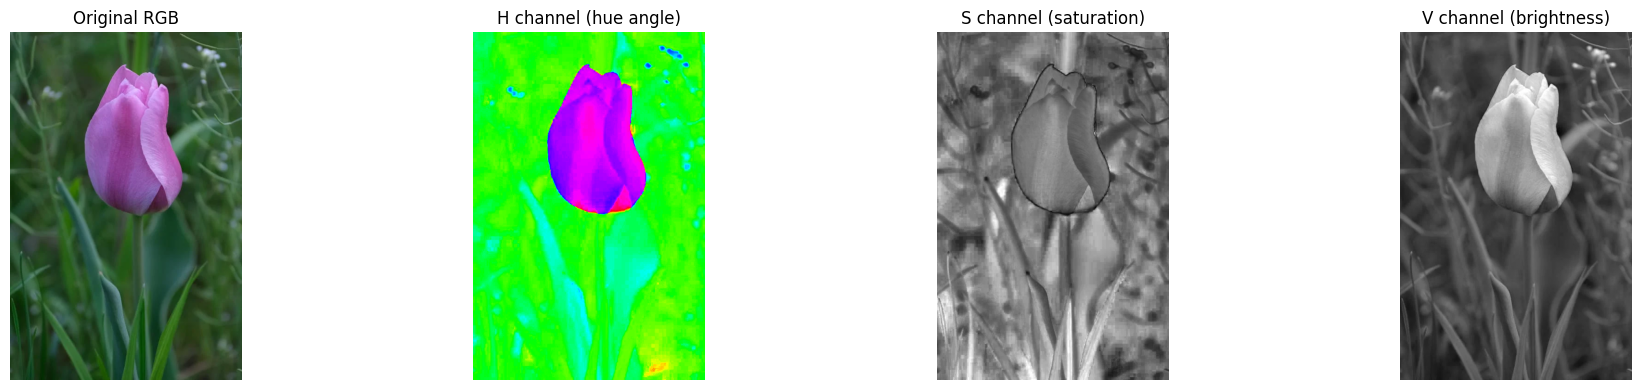

In [57]:
# Tulip image
img_tulip_bgr = cv2.imread('tulip.png')
img_tulip_rgb = cv2.cvtColor(img_tulip_bgr, cv2.COLOR_BGR2RGB)
img_tulip_hsv = cv2.cvtColor(img_tulip_rgb, cv2.COLOR_RGB2HSV)

# Split into individual channels
H_ch = img_tulip_hsv[:,:,0]
S_ch = img_tulip_hsv[:,:,1]
V_ch = img_tulip_hsv[:,:,2]

show_images(
    [img_tulip_rgb, H_ch, S_ch, V_ch],
    ['Original RGB', 'H channel (hue angle)', 'S channel (saturation)', 'V channel (brightness)'],
    cmap_list=[None, 'hsv', 'gray', 'gray']
)

## HSV in OpenCV - What's Different

OpenCV implements HSV with two important differences from the textbook definition that will silently break your code if you aren't aware of them.

### Range scaling

|               | Standard HSV | OpenCV |
| :----------- | :------: | ----: |
| Hue        |   0° – 360°   |   0 – 179   |
| Saturation |   0.0 – 1.0   |   0 – 255   |
| Value    |   0.0 – 1.0   |   0 – 255   |

Hue for standard HSV is a full rotation around the colour wheel however in OpenCV it was halved to fit in an 8-bit unsigned integer

This means pure red, which sits at 0° and 360° in standard HSV, sits at 0 and 179 in OpenCV. If you look up a hue threshold online and apply it directly without halving, your mask will select the wrong colours entirely. Always divide standard hue values by 2 before passing them to cv2.inRange().

### Cylinder, not cone

The textbook model of HSV is a cone: the colour circle is widest at the top (full brightness) and tapers to a single point at the bottom (black). This makes geometric sense — a dark pixel can't be saturated.

OpenCV treats HSV as a cylinder: the colour circle stays the same width all the way down, regardless of V. There is no enforcement that low-V pixels must have low S.

The practical consequence is that pixels near black can report high saturation values in OpenCV's encoding, even though visually they have no discernible colour. If you are thresholding on saturation to filter out "colourless" pixels, be aware that very dark pixels may pass your saturation filter and produce unexpected results. Adding a minimum V threshold alongside your S threshold handles this.

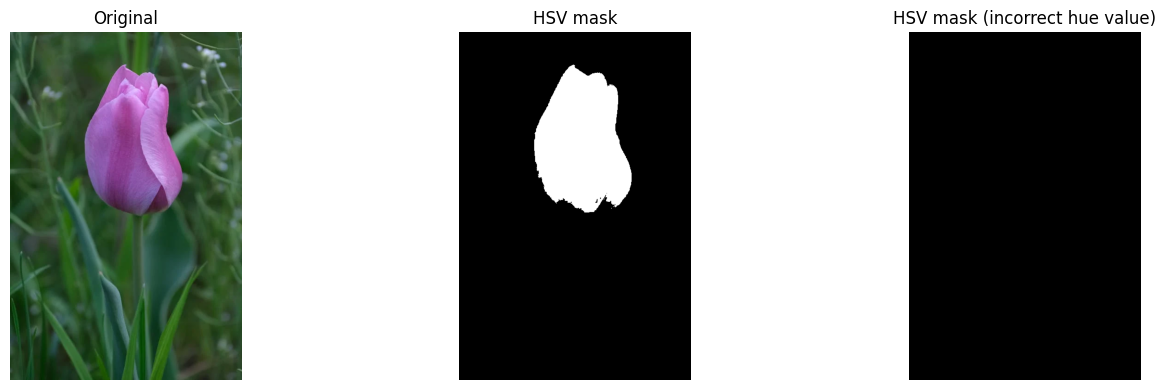

In [58]:
# Correct Range
# Define the hue range for the tulip (pink around H=147) in OpenCV H units
lower_hsv_cv = np.array([130,  50,  80])
upper_hsv_cv = np.array([170, 255, 255])

# inRange produces a binary mask
mask_hsv_cv = cv2.inRange(img_tulip_hsv, lower_hsv_cv, upper_hsv_cv)

# Incorrect Range
lower_hsv = np.array([260,  50,  80])
upper_hsv = np.array([340, 255, 255])

mask_hsv = cv2.inRange(img_tulip_hsv, lower_hsv, upper_hsv)

show_images(
    [img_tulip_rgb, mask_hsv_cv, mask_hsv],
    ['Original',
     'HSV mask',
     'HSV mask (incorrect hue value)'],
    cmap_list=[None, 'gray', 'gray']
)

## Colour masking and segmentation

HSV becomes especially useful for colour-based segmentation — for example, isolating a pink tulip from a green background.

### Using HSV

We define a range of hue values that match pink/magenta and use `cv2.inRange()` to create a binary mask. Because hue is separated from brightness, the tulip can still be detected in both bright and shadowed areas.

In OpenCV, the tulip’s hue is around **H ≈ 147**, so we allow a small tolerance around that value to capture variation across the petals.

### Why RGB struggles

We also try the same task in RGB by matching pixels close to a sampled pink colour, from the center of the tulip. The results are much less reliable because lighting changes alter the R, G, and B values directly.

Shadowed petals often get missed, while some background pixels can accidentally match the threshold. In RGB, colour and brightness are tightly mixed together, making robust segmentation much harder.

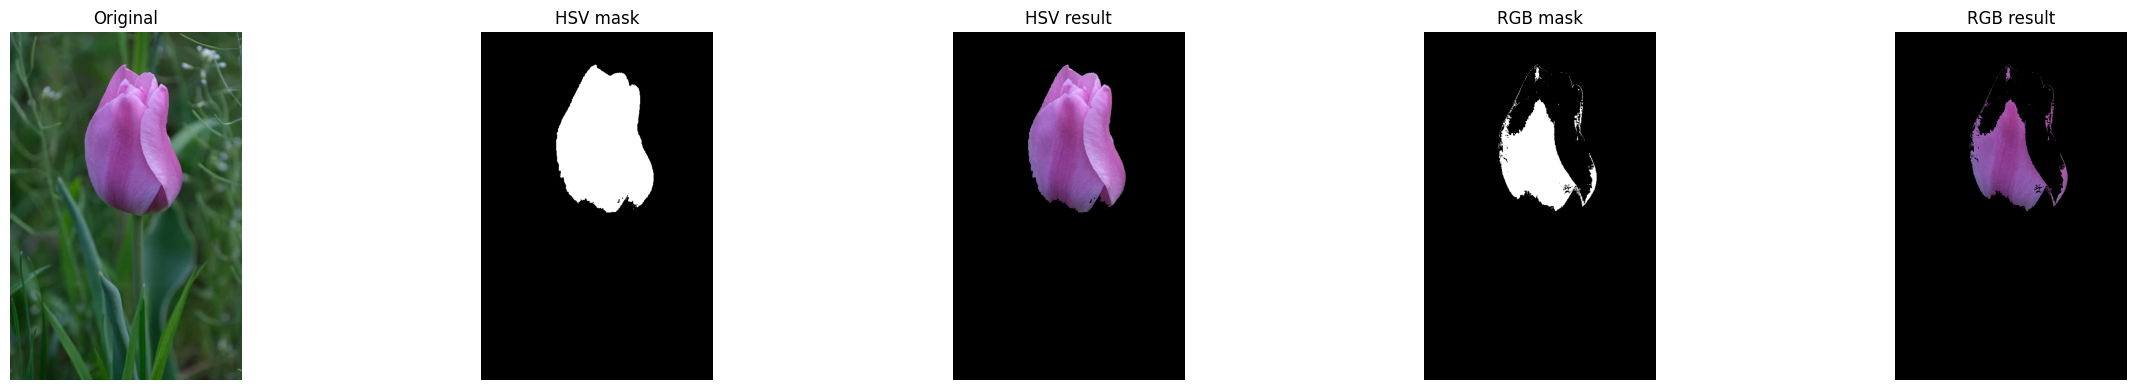


HSV mask: 47,395 pixels selected  (12.6% of image)
RGB mask: 23,840 pixels selected  (6.4% of image)


In [59]:
# HSV masking
lower_hsv = np.array([130,  50,  80])
upper_hsv = np.array([170, 255, 255])

mask_hsv = cv2.inRange(img_tulip_hsv, lower_hsv, upper_hsv)
result_hsv = cv2.bitwise_and(img_tulip_rgb, img_tulip_rgb, mask=mask_hsv)

# RGB MASKING (for comparison)
# Sample a  pink pixel from the tulip centre
sample_pixel = img_tulip_rgb[250, 250].astype(np.float32)

# Accept pixels within Euclidean distance of 60 in RGB space
img_float = img_tulip_rgb.astype(np.float32)
rgb_dist = np.sqrt(np.sum((img_float - sample_pixel) ** 2, axis=2))
mask_rgb = (rgb_dist < 60).astype(np.uint8) * 255
result_rgb = cv2.bitwise_and(img_tulip_rgb, img_tulip_rgb, mask=mask_rgb)

# Display
show_images(
    [img_tulip_rgb, mask_hsv, result_hsv, mask_rgb, result_rgb],
    ['Original',
     'HSV mask',
     'HSV result',
     'RGB mask',
     'RGB result'],
    cmap_list=[None, 'gray', None, 'gray', None]
)

print(f"\nHSV mask: {np.sum(mask_hsv > 0):,} pixels selected  ({100*np.mean(mask_hsv>0):.1f}% of image)")
print(f"RGB mask: {np.sum(mask_rgb > 0):,} pixels selected  ({100*np.mean(mask_rgb>0):.1f}% of image)")

# Observe the HSV mask cleanly captures the full tulip including shadowed regions


## The hue instability problem

HSV has an important limitation: *hue becomes unreliable when saturation is very low.*

In simple terms, grey pixels do not really have a colour. In the HSV model, all greys sit along the centre axis where saturation is zero, so the hue value becomes mathematically undefined.

Most implementations handle this by assigning an arbitrary hue value, often `H = 0`. The problem is that grey or near-white pixels can then accidentally appear to belong to a real colour range.

This can cause two common issues:

- grey regions may be incorrectly detected as coloured objects,
- pale or washed-out colours may become unstable and harder to detect.

**The solution**

When using hue-based masking, always include a **minimum saturation threshold**. In OpenCV, this is done with the `S_min` value in `cv2.inRange()`.

For example, our mask uses `S_min = 50` to ignore near-grey pixels entirely, making the segmentation much more reliable.

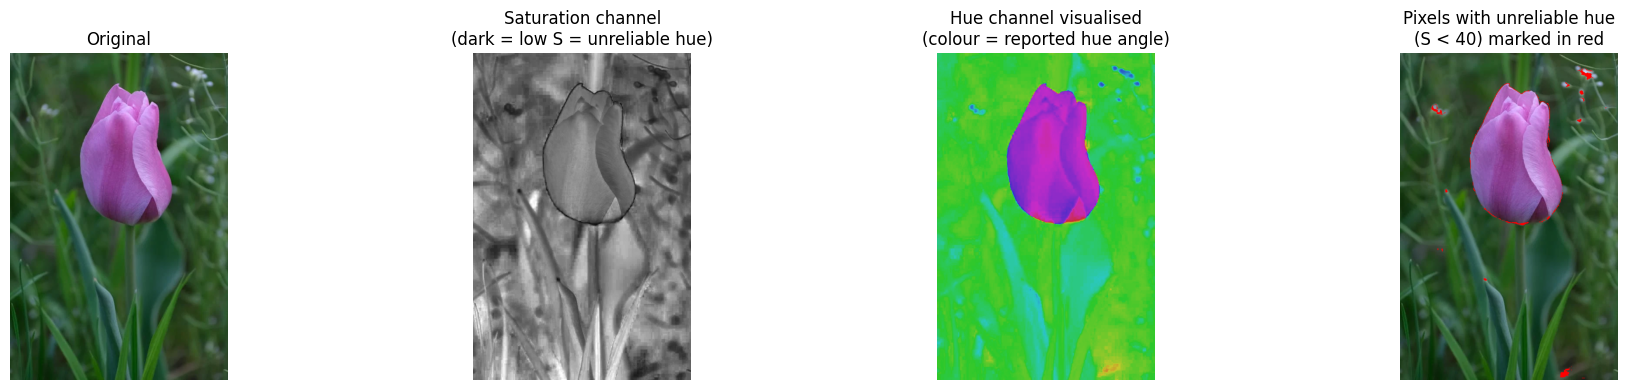

In [60]:
# Visualise hue instability in low-saturation regions
S_ch_float = img_tulip_hsv[:,:,1].astype(np.float32)

# Create a pure hue visualisation: set S=200, V=200 for all pixels, keep only the H channel
hsv_hue_vis = np.stack([
    img_tulip_hsv[:,:,0],
    np.full(img_tulip_hsv.shape[:2], 200, dtype=np.uint8),
    np.full(img_tulip_hsv.shape[:2], 200, dtype=np.uint8)
], axis=2)
hue_visualised = cv2.cvtColor(hsv_hue_vis, cv2.COLOR_HSV2RGB)

# Identify pixels where hue is unreliable (S < 40)
low_sat_mask = S_ch_float < 40
unreliable_overlay = img_tulip_rgb.copy()
unreliable_overlay[low_sat_mask] = [255, 0, 0]  # mark as red

show_images(
    [img_tulip_rgb,
     img_tulip_hsv[:,:,1],
     hue_visualised,
     unreliable_overlay],
    ['Original',
     'Saturation channel\n(dark = low S = unreliable hue)',
     'Hue channel visualised\n(colour = reported hue angle)',
     'Pixels with unreliable hue\n(S < 40) marked in red'],
    cmap_list=[None, 'gray', None, None]
)

>HSV handled the problem of separating colour from brightness for human-friendly tasks. The next colour space handles a different problem, **compression**, by separating the same brightness information but using a mathematical structure designed for efficient storage.

# 3. YCbCr - Luma and Chrominance

Unlike RGB, YCbCr separates image information into brightness and colour components. This makes it highly effective for image and video compression, since human vision is more sensitive to brightness detail than colour detail.

YCbCr consists of three channels:

- **Y (Luma):** brightness and structural image detail
- **Cb:** blue-difference chroma component
- **Cr:** red-difference chroma component

Since most perceptual detail is contained in the Y channel, the chrominance channels can be compressed more heavily with minimal perceived quality loss. This principle is widely used in JPEG, MPEG, and H.264 compression.

Although Cb and Cr are often visualised using blue and red colour maps, they do not represent actual blue or red images. Instead, they encode chrominance differences relative to luminance.

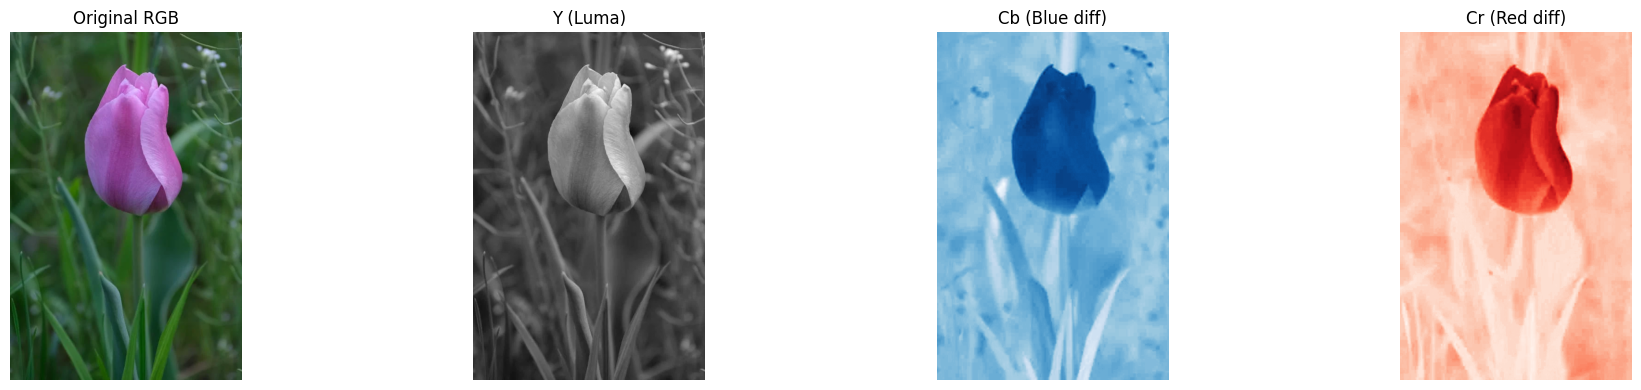

In [61]:
# Convert RGB -> YCrCb
# Tulip image already loaded as img_tulip_rgb
img_ycbcr = cv2.cvtColor(img_tulip_rgb, cv2.COLOR_RGB2YCrCb)

# OpenCV stores channels as: Y, Cr, Cb
Y_ch  = img_ycbcr[:, :, 0]
Cr_ch = img_ycbcr[:, :, 1]
Cb_ch = img_ycbcr[:, :, 2]

# Display images
show_images(
    [img_tulip_rgb, Y_ch, Cb_ch, Cr_ch],
    ['Original RGB', 'Y (Luma)', 'Cb (Blue diff)', 'Cr (Red diff)'],
    cmap_list=[None, 'gray', 'Blues', 'Reds']
)

The Y channel retains structural detail, while Cb and Cr represent chrominance variation. These are visualised as intensity maps rather than true colour images.

## Chroma Subsampling

Chroma subsampling reduces the resolution of the chrominance channels while preserving full resolution in luminance. Since the human visual system is less sensitive to colour detail than brightness, this allows significant data reduction with minimal perceptual loss.

Standard formats include:

- 4:4:4 → no subsampling
- 4:2:2 → reduced horizontal colour resolution
- 4:2:0 → reduced horizontal and vertical colour resolution

To illustrate this, both standard (4:2:0) and extreme subsampling are applied. The extreme case demonstrates visible colour degradation, showing the trade-off between compression and quality.

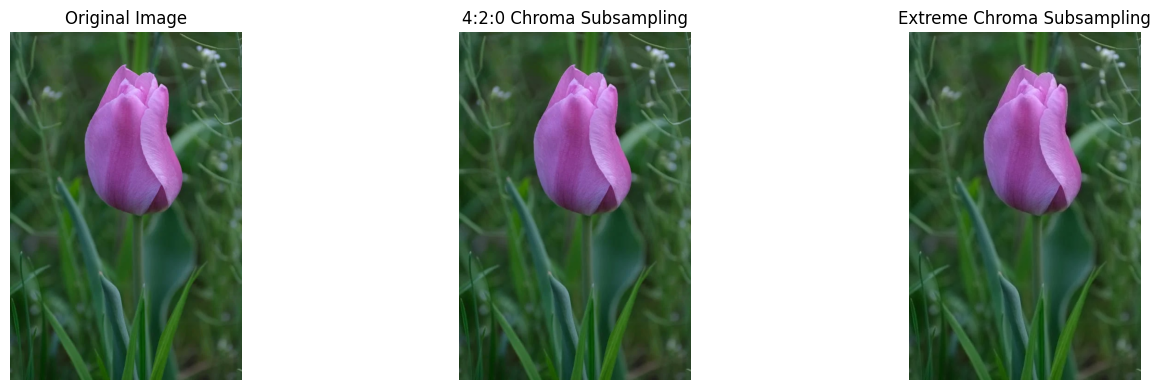

In [62]:
# Standard 4:2:0 subsampling
Cb_small = cv2.resize(Cb_ch, (Cb_ch.shape[1]//2, Cb_ch.shape[0]//2), interpolation=cv2.INTER_LINEAR)
Cr_small = cv2.resize(Cr_ch, (Cr_ch.shape[1]//2, Cr_ch.shape[0]//2), interpolation=cv2.INTER_LINEAR)

Cb_up = cv2.resize(Cb_small, (Cb_ch.shape[1], Cb_ch.shape[0]), interpolation=cv2.INTER_LINEAR)
Cr_up = cv2.resize(Cr_small, (Cr_ch.shape[1], Cr_ch.shape[0]), interpolation=cv2.INTER_LINEAR)

img_subsampled = cv2.merge([Y_ch, Cr_up, Cb_up])
img_subsampled = cv2.cvtColor(img_subsampled, cv2.COLOR_YCrCb2RGB)


# Extreme chroma subsampling
Cb_extreme = cv2.resize(Cb_ch, (Cb_ch.shape[1]//8, Cb_ch.shape[0]//8), interpolation=cv2.INTER_LINEAR)
Cr_extreme = cv2.resize(Cr_ch, (Cr_ch.shape[1]//8, Cr_ch.shape[0]//8), interpolation=cv2.INTER_LINEAR)

Cb_extreme_up = cv2.resize(Cb_extreme, (Cb_ch.shape[1], Cb_ch.shape[0]), interpolation=cv2.INTER_LINEAR)
Cr_extreme_up = cv2.resize(Cr_extreme, (Cr_ch.shape[1], Cr_ch.shape[0]), interpolation=cv2.INTER_LINEAR)

img_extreme = cv2.merge([Y_ch, Cr_extreme_up, Cb_extreme_up])
img_extreme = cv2.cvtColor(img_extreme, cv2.COLOR_YCrCb2RGB)

# Displaying results
show_images(
    [img_tulip_rgb, img_subsampled, img_extreme],
    [
        'Original Image',
        '4:2:0 Chroma Subsampling',
        'Extreme Chroma Subsampling'
    ],
    cmap_list=[None, None, None]
)


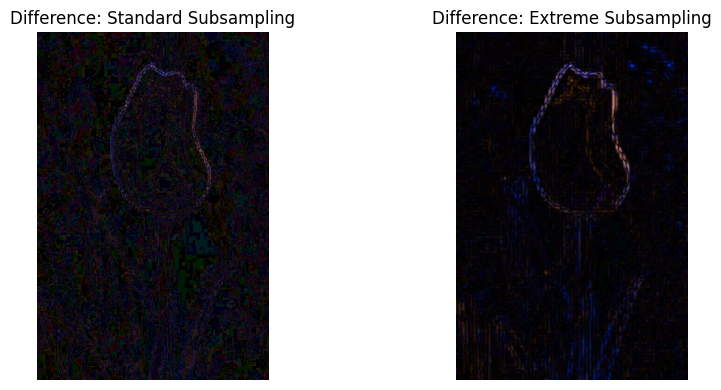

In [63]:
# Difference images
diff_normal = np.abs(img_tulip_rgb.astype(np.int16) - img_subsampled.astype(np.int16))
diff_extreme = np.abs(img_tulip_rgb.astype(np.int16) - img_extreme.astype(np.int16))

diff_normal = cv2.normalize(diff_normal, None, 0, 255, cv2.NORM_MINMAX)
diff_extreme = cv2.normalize(diff_extreme, None, 0, 255, cv2.NORM_MINMAX)

show_images(
    [diff_normal, diff_extreme],
    [
        'Difference: Standard Subsampling',
        'Difference: Extreme Subsampling'
    ],
    cmap_list=['gray', 'gray']
)

## Skin Detection using YCbCr

YCbCr is commonly used in skin detection because skin tones tend to cluster within a narrow range of chrominance values, regardless of lighting conditions. This makes segmentation in Cb and Cr more robust than RGB-based thresholding.

A threshold range is applied to the Cb and Cr channels to isolate skin regions. However, since the method relies purely on chrominance similarity, non-skin regions such as hair or shadows may also be detected.

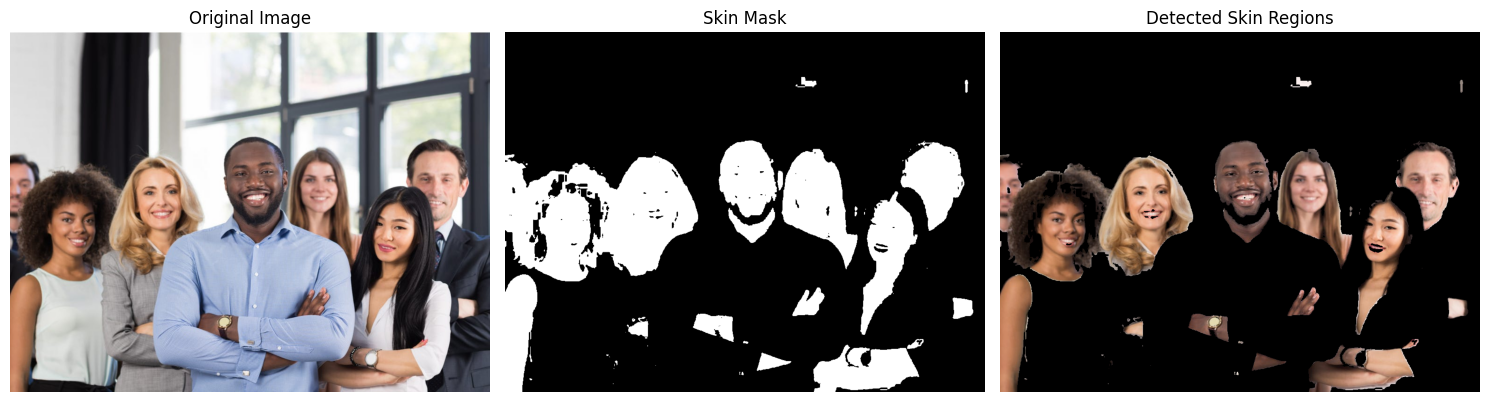

In [64]:
# Load People image
img_skin_bgr = cv2.imread('people.jpg')
img_skin_rgb = cv2.cvtColor(img_skin_bgr, cv2.COLOR_BGR2RGB)
# Convert to YCbCr
img_skin_ycbcr = cv2.cvtColor(img_skin_rgb, cv2.COLOR_RGB2YCrCb)

# OpenCV order: Y, Cr, Cb
Y  = img_skin_ycbcr[:,:,0]
Cr = img_skin_ycbcr[:,:,1]
Cb = img_skin_ycbcr[:,:,2]

# Skin colour thresholds
skin_mask = cv2.inRange(img_skin_ycbcr, (0, 133, 77), (255, 173, 127))

# Apply mask
skin_detected = cv2.bitwise_and(
    img_skin_rgb,
    img_skin_rgb,
    mask=skin_mask
)

# Display results
show_images(
    [img_skin_rgb, skin_mask, skin_detected],
    ['Original Image', 'Skin Mask', 'Detected Skin Regions'],
    cmap_list=[None, 'gray', None]
)

## Incorrect Conversion Standard / Colour Cast
Different YCbCr standards (e.g. BT.601 vs BT.709) use different conversion coefficients depending on application. If the wrong standard is applied, the reconstructed image may exhibit colour shifts known as colour casts.

This occurs because luminance and chrominance are misinterpreted during conversion

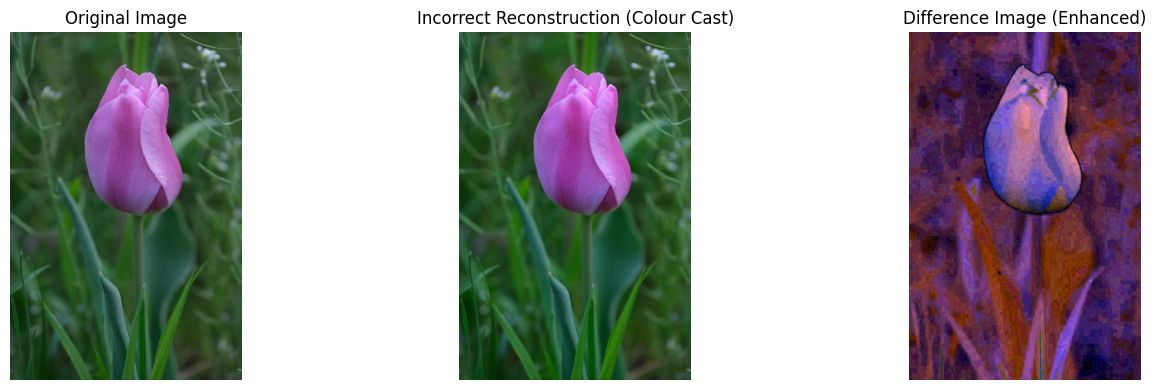

In [65]:
# Convert to YCbCr first
img_ycbcr = cv2.cvtColor(img_tulip_rgb, cv2.COLOR_RGB2YCrCb)

Y  = img_ycbcr[:,:,0].astype(np.float32)
Cr = img_ycbcr[:,:,1].astype(np.float32) - 128
Cb = img_ycbcr[:,:,2].astype(np.float32) - 128

# INTENTIONALLY stronger incorrect reconstruction (colour cast)
R_wrong = Y + 1.8 * Cr
G_wrong = Y - 0.4 * Cb - 0.9 * Cr
B_wrong = Y + 2.2 * Cb

img_wrong = cv2.merge([
    np.clip(R_wrong, 0, 255),
    np.clip(G_wrong, 0, 255),
    np.clip(B_wrong, 0, 255)
]).astype(np.uint8)

# Compute visible difference
diff = cv2.absdiff(img_tulip_rgb, img_wrong)

# Boost visibility (VERY important)
diff_boost = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)

show_images(
    [img_tulip_rgb, img_wrong, diff_boost],
    ['Original Image', 'Incorrect Reconstruction (Colour Cast)', 'Difference Image (Enhanced)'],
    cmap_list=[None, None, 'gray']
)

The difference image represents the pixel-wise absolute difference between the original and reconstructed image. Brighter regions indicate larger colour distortion, while darker regions indicate minimal change.

In this example, higher differences appear mainly in saturated regions such as the flower petals, where chrominance errors have the strongest perceptual effect. The image is normalised to improve visibility, as raw differences are typically small.

>YCbCr separates brightness from colour for compression, for storing and transmitting data efficiently. LAB approaches the same separation from a completely different angle: not for storage, but for matching how humans perceive colour differences. This shift in purpose changes everything about the structure of the space.

# 4. LAB

Lab (CIELAB) is a colour space designed around human visual perception rather than hardware or compression efficiency. Unlike RGB, which mixes brightness and colour across all three channels, LAB seperates them completely:

- **L\* (Lightness)** -brightness only, from 0 (black) to 100 (white). Completely independent of colour.
- **a\*** -the green–red opponent axis. Negative= green, positive= red.
- **b\*** -the blue–yellow opponent axis. Negative= blue, positive= yellow.

Its key property is **perceptual uniformity**: equal numerical distances in LAB correspond to roughly equal perceived colour differences. This makes it the standard choice for colour difference measurement (ΔE) and colour correction.

## Channel splitting:

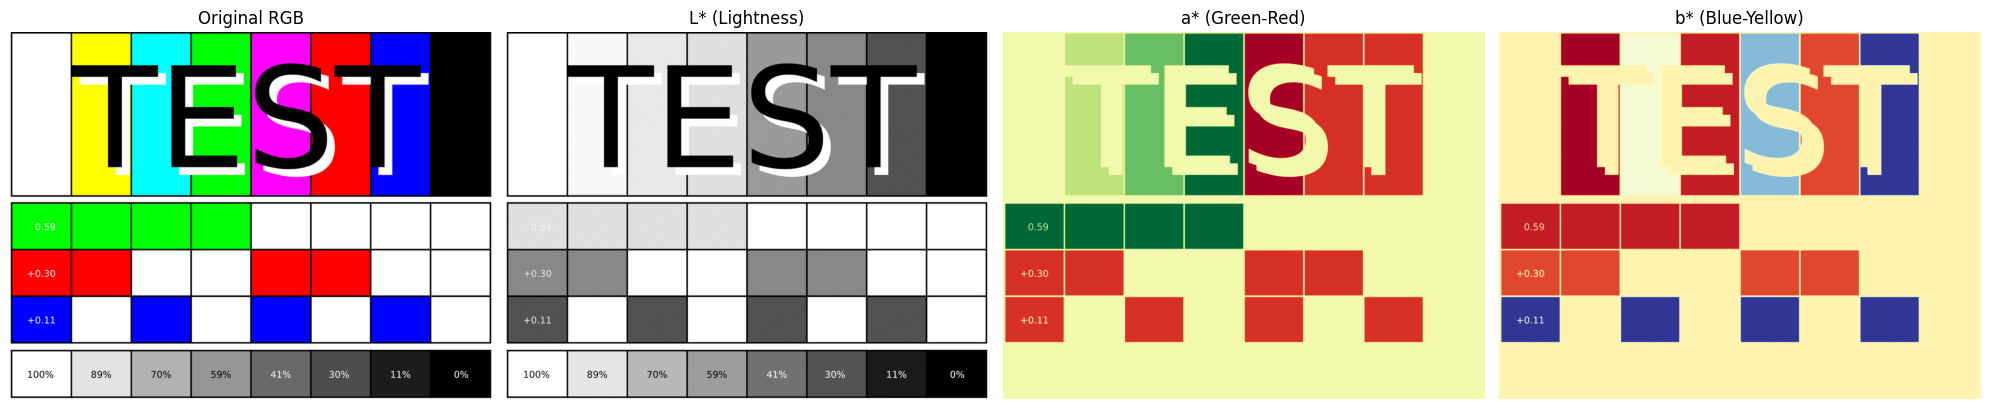

In [66]:
#converting to LAB using OpenCV
#OpenCV expects BGR input for this conversion

img_lab=cv2.cvtColor(img_rgb, cv2.COLOR_RGB2Lab)

#splitting into individual channels
L_ch=img_lab[:,:,0] #L*: 0-100 
a_ch=img_lab[:,:,1] #a*: -128 to 127 
b_ch=img_lab[:,:,2] #b*: -128 to 127

show_images(
    [img_rgb, L_ch, a_ch, b_ch],
    ['Original RGB', 'L* (Lightness)', 'a* (Green-Red)', 'b* (Blue-Yellow)'],
    cmap_list=[None,'gray', 'RdYlGn_r', 'RdYlBu_r']
)

## Rescaling OpenCV LAB:

In [67]:
#converting OpenCV uint8 LAB to true float L*a*b* values

img_lab_float=img_lab.astype(np.float32)
img_lab_float[:,:,0]=img_lab_float[:,:,0] * 100/255 #L*: 0-255 -> 0-100
img_lab_float[:,:,1]=img_lab_float[:,:,1] -128 #a*: 0-255 -> -128 to +127
img_lab_float[:,:,2]=img_lab_float[:,:,2] -128 #b*: 0-255 -> -128 to +127

print("L* range:", img_lab_float[:,:,0].min().round(1), "to", img_lab_float[:,:,0].max().round(1))
print("a* range:", img_lab_float[:,:,1].min().round(1), "to", img_lab_float[:,:,1].max().round(1))
print("b* range:", img_lab_float[:,:,2].min().round(1), "to", img_lab_float[:,:,2].max().round(1))

L* range: 0.0 to 100.0
a* range: -86.0 to 98.0
b* range: -108.0 to 95.0


## Perceptual Uniformity - Why LAB Distance Means Something

RGB distance does not reliably reflect how different two colours look. Equal numerical steps in RGB can produce very different visual jumps depending on where in the colour spectrum you are.

LAB is designed so that equal numerical steps look visually equal, a property called perceptual uniformity. The comparison below demonstrates this by stepping through equal intervals of a colour channel in both RGB and LAB and showing the results side by side.

## Perceptual uniformity demonstration:

In [68]:
#creating colour strips with equal numerical steps in RGB vs LAB 
#and showing how differently those steps look visually

n_steps=8
strip_height=60
strip_width=60

Equal steps in **RGB** (red channel):

In [69]:
rgb_strips=[]
for i in range(n_steps):
    val=int(i*255/(n_steps-1))
    strip=np.zeros((strip_height, strip_width, 3),dtype=np.uint8)
    strip[:,:]=[val,80,80] #varying R and keeping G and B fixed
    rgb_strips.append(strip)
rgb_row=np.hstack(rgb_strips)

Equal steps in **LAB** (L* channel, neutral grey axis):

In [70]:
lab_strips=[]
for i in range (n_steps):
    L_val= i*100 / (n_steps-1) #0 to 100 in true L* units
    L_ocv=int(L_val * 255/100) #back to OpenCV uint8
    strip_lab=np.zeros((strip_height, strip_width,3),dtype=np.uint8)
    strip_lab[:,:]=[L_ocv, 128,128]# neutral grey ( a*=0, b*=0) at varying L*
    strip_bgr = cv2.cvtColor(strip_lab, cv2.COLOR_Lab2RGB)
    lab_strips.append(strip_bgr)
lab_row = np.hstack(lab_strips)

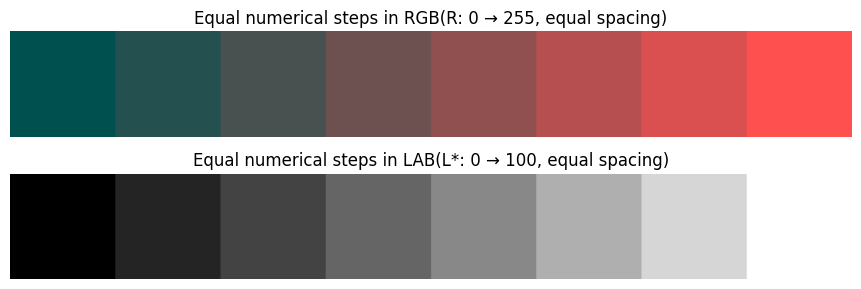

In [71]:
#displaying both strips 
fig, axes=plt.subplots(2,1,figsize=(12,3))
axes[0].imshow(rgb_row)
axes[0].set_title('Equal numerical steps in RGB(R: 0 → 255, equal spacing)')
axes[0].axis('off')
axes[1].imshow(lab_row)
axes[1].set_title('Equal numerical steps in LAB(L*: 0 → 100, equal spacing)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Notice how the LAB steps look more evenly spaced perceptually. The RGB steps bunch up in the dark region and spread out in the bright region.

## Delta E (ΔE) — Measuring Perceptual Colour Difference

Because LAB is perceptually uniform, the straight-line (Euclidean) distance between two points in LAB space gives a meaningful measure of how different two colours look to a human observer. This metric is called **Delta E (ΔE)**.

The simplest version (CIE76) is:

`ΔE = √[(ΔL\*)² + (Δa\*)² + (Δb\*)²]`

This is used in manufacturing, printing, and medical imaging to enforce colour consistency objectively.

## ΔE calculation:

In [72]:
def delta_e_cie76(lab1, lab2):
    diff=np.array(lab1, dtype=np.float32)-np.array (lab2, dtype=np.float32)
    return float(np.sqrt(np.sum(diff ** 2)))

#example colour pairs
pairs=[
    ("Near-identical reds",[50,60,30], [50,60.5,30.2]),
    ("Slightly different blues",[40,-10,-40], [40,-10,-45]),
    ("Clearly different colours",[70,20,40], [40,-30,-20]),
    ("Black vs white",[0,0,0], [100,0,0]),
]

Table output of **colour differences** and **perceptual verdicts**:

In [73]:
print(f"{'Pair':<30}{'LAB 1':<22}{'LAB 2':<22}{'ΔE':>6}Verdict")
print("-" * 95)
for name, lab1, lab2 in pairs:
    de = delta_e_cie76(lab1, lab2)
    if de < 1.0:
        verdict = "imperceptible"
    elif de < 2.0:
        verdict = "trained eye only"
    elif de < 10:
        verdict = "clearly visible"
    else:
        verdict = "very different"
    print(f"{name:<30} {str(lab1):<22} {str(lab2):<22} {de:>6.2f}  {verdict}")

Pair                          LAB 1                 LAB 2                     ΔEVerdict
-----------------------------------------------------------------------------------------------
Near-identical reds            [50, 60, 30]           [50, 60.5, 30.2]         0.54  imperceptible
Slightly different blues       [40, -10, -40]         [40, -10, -45]           5.00  clearly visible
Clearly different colours      [70, 20, 40]           [40, -30, -20]          83.67  very different
Black vs white                 [0, 0, 0]              [100, 0, 0]            100.00  very different


## ΔE across the image 

Compute per-pixel Delta E between the original image and a shifted version

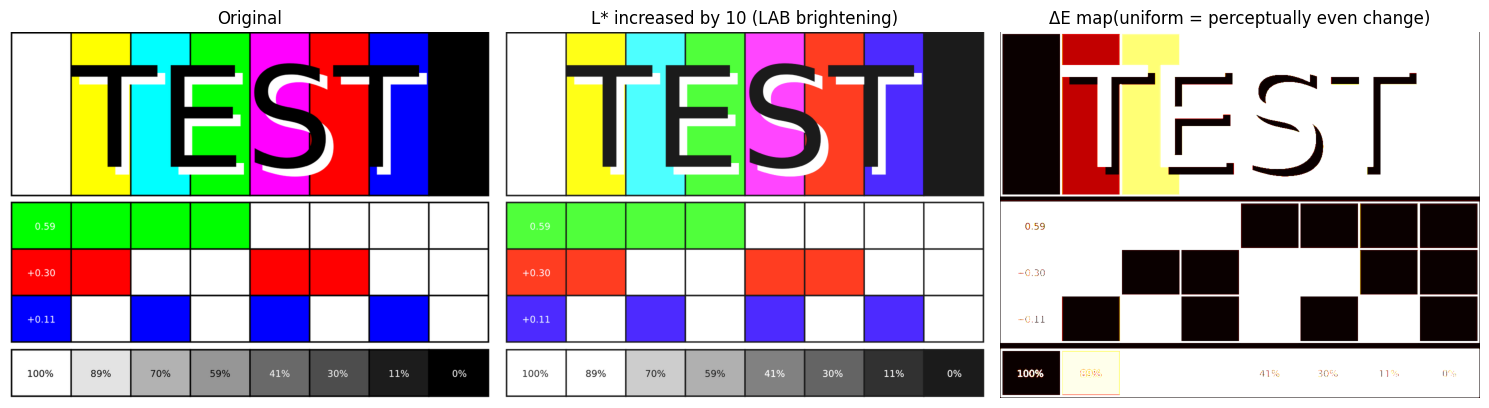

Mean ΔE across image:6.64
Max  ΔE across image:10.00


In [74]:
# Shift: increase L* by 10 (brighten uniformly), this is perceptually even in LAB
lab_f = img_lab_float.copy()
lab_shifted = img_lab_float.copy()
lab_shifted[:,:,0] = np.clip(lab_shifted[:,:,0] + 10, 0, 100)  # brighten L* by 10 units

# Per-pixel Delta E map
delta_e_map = np.sqrt(
    (lab_f[:,:,0] - lab_shifted[:,:,0])**2 +(lab_f[:,:,1] - lab_shifted[:,:,1])**2 +
    (lab_f[:,:,2] - lab_shifted[:,:,2])**2
)

# Reconstruct the brightened image for display
lab_shifted_ocv = lab_shifted.copy()
lab_shifted_ocv[:,:,0]= lab_shifted_ocv[:,:,0] *255 /100
lab_shifted_ocv[:,:,1]= lab_shifted_ocv[:,:,1] +128
lab_shifted_ocv[:,:,2]= lab_shifted_ocv[:,:,2] +128
img_brightened = cv2.cvtColor(lab_shifted_ocv.astype(np.uint8), cv2.COLOR_Lab2RGB)

show_images(
    [img_rgb, img_brightened, delta_e_map],
    ['Original','L* increased by 10 (LAB brightening)','ΔE map(uniform = perceptually even change)'],
    cmap_list=[None, None,'hot']
)

print(f"Mean ΔE across image:{delta_e_map.mean():.2f}")
print(f"Max  ΔE across image:{delta_e_map.max():.2f}")

A uniform ΔE map confirms the change was perceptually even across all regions.

## LAB-based Image Enhancement vs RGB-based

One practical advantage of LAB is that you can enhance brightness and contrast **without touching colour**. In RGB, any adjustment to brightness requires changing all three channels, which often shifts hue and saturation as a side effect.

Below we apply the same contrast stretch to both LAB (L\* channel only) and RGB (all channels) and compare the results.

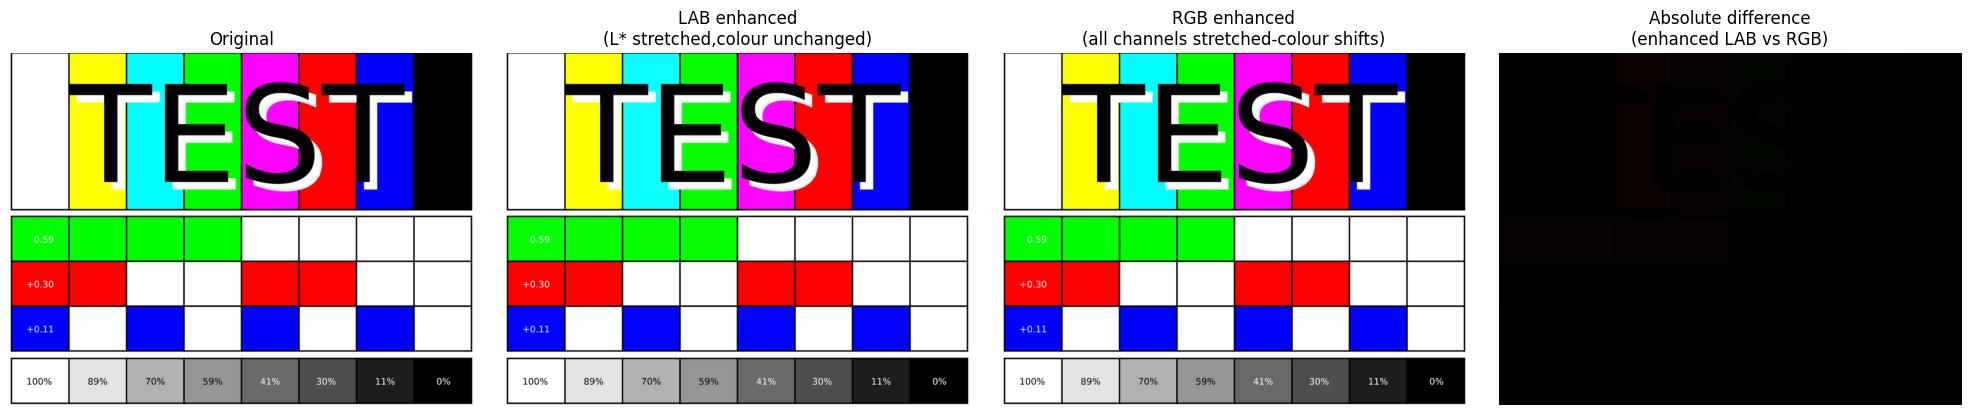

In [75]:
#LAB-based contrast enhancement(L* channel only)
lab_enhanced = img_lab_float.copy()

#Stretching L* to fill the full 0-100 range
L = lab_enhanced[:,:,0]
L_stretched = (L - L.min()) / (L.max() - L.min()) * 100
lab_enhanced[:,:,0] = L_stretched

#Converting back to RGB for display
lab_enh_ocv = lab_enhanced.copy()
lab_enh_ocv[:,:,0]= lab_enh_ocv[:,:,0] * 255 / 100
lab_enh_ocv[:,:,1]= lab_enh_ocv[:,:,1] + 128
lab_enh_ocv[:,:,2]= lab_enh_ocv[:,:,2] + 128
img_lab_enhanced= cv2.cvtColor(lab_enh_ocv.astype(np.uint8), cv2.COLOR_Lab2RGB)

#RGB-based contrast enhancement(all channels stretched independently)
img_rgb_enhanced = img_rgb.copy().astype(np.float32)
for c in range(3):
    ch = img_rgb_enhanced[:,:,c]
    img_rgb_enhanced[:,:,c] = (ch - ch.min()) / (ch.max() - ch.min()) * 255
img_rgb_enhanced= img_rgb_enhanced.astype(np.uint8)

show_images(
    [img_rgb, img_lab_enhanced, img_rgb_enhanced, np.abs(img_lab_enhanced.astype(np.int16) - img_rgb_enhanced.astype(np.int16))],
    ['Original',
     'LAB enhanced\n(L* stretched,colour unchanged)',
     'RGB enhanced\n(all channels stretched-colour shifts)',
     'Absolute difference\n(enhanced LAB vs RGB)'],
    cmap_list=[None, None, None, 'hot']
)

LAB enhancement preserves hue and saturation. RGB enhancement may introduce colour casts because channels are stretched independently.

>Each colour space covered so far was designed to solve a specific problem; display, intuition, compression, or perception. Moving image data between them is what makes them useful in practice. The final section walks through the mathematical equations that translate colour data from one space to another, and shows what breaks when those equations are misapplied.

# 5. Conversions
Colour space conversion is the mathematical process of translating colour data from one representation to another. Each colour space explored in this notebook was designed for a specific purpose: 
* RGB for display
* HSV for human-intuitive colour selection
* YCbCr for compression
* LAB for perceptual uniformity

Moving between them requires precise equations, as using the wrong formula or skipping a step introduces errors that range from subtle colour shifts to completely incorrect output.

This section walks through the conversion equations manually using NumPy, implementing the **classical real-valued floating-point method** throughout. This approach is chosen because the notebook runs in a Python environment where floating-point operations are natively supported, making the underlying mathematics explicit without the hardware constraints that need integer-based or lookup table alternatives. Each forward conversion (RGB to target space) is followed by its inverse, with a difference map confirming the round-trip accuracy. Common implementation errors are demonstrated at the end to show what breaks and why.

In [76]:
# Normalised float version [0,1] used in manual calculations
img_norm = img_rgb.astype(np.float32) / 255.
print(f"Image shape: {img_norm.shape}")
print(f"Original uint8 range: 0–255   |   Normalised float range: {img_norm.min():.2f}–{img_norm.max():.2f}")

Image shape: (732, 960, 3)
Original uint8 range: 0–255   |   Normalised float range: 0.00–1.00


All manual conversions in this section work on normalised float values in [0,1] rather than uint8 [0,255]. This avoids overflow during multiplication and keeps the maths clean. The conversion functions assume normalised input.

> RGB shows the limits of mixing colour and brightness into the same three values. Tasks that depend on identifying what colour something is (regardless of how brightly it is lit) need a colour space that pulls these properties apart. HSV does exactly that.

### a. RGB -> HSV
RGB stores colour as three correlated light intensities. HSV reorganises this into **Hue** (colour type, 0–360°), **Saturation** (colour purity), and **Value** (brightness). The conversion is nonlinear and requires a piecewise hue calculation based on which RGB component is dominant. We implement this manually first so the mathematics is visible, then verify against OpenCV.

`Step 1`: Find the maximum and minimum of each pixel's three channels. Value (V) is simply the brightest channel; delta is the range, telling us how colourful the pixel is.

In [77]:
R, G, B = img_norm[:,:,0], img_norm[:,:,1], img_norm[:,:,2]

V = np.max(img_norm, axis=2)
m = np.min(img_norm, axis=2)
delta = V - m

print(f"V range: {V.min():.3f} to {V.max():.3f}   (brightness)")
print(f"delta range: {delta.min():.3f} to {delta.max():.3f}   (colour intensity)")

V range: 0.000 to 1.000   (brightness)
delta range: 0.000 to 1.000   (colour intensity)


`Step 2`: Saturation is the ratio of colour range to brightness. Black pixels have V=0, so we guard against division by zero by temporarily replacing zero V values with 1 before dividing (the np.where then correctly assigns S=0 to those pixels regardless).

In [78]:
# Safe division: replace 0s with 1 temporarily to avoid divide-by-zero
V_safe = np.where(V == 0, 1, V) 
S = np.where(V == 0, 0, delta / V_safe)

print(f"S range: {S.min():.3f} to {S.max():.3f}")

S range: 0.000 to 1.000


`Step 3`: Hue is a piecewise angle determined by which RGB channel is dominant. The same +2 and +4 sector offsets in the formula correspond to the 120° and 240° positions on the colour wheel where green and blue dominate. Achromatic pixels (delta=0) have undefined hue (set to 0 by convention).

In [79]:
H = np.zeros_like(V)
delta_safe = np.where(delta == 0, 1, delta)

mask_r = (V == R) & (delta != 0)
mask_g = (V == G) & (delta != 0)
mask_b = (V == B) & (delta != 0)

H[mask_r] = 60 * (((G - B) / delta_safe) % 6)[mask_r]
H[mask_g] = 60 * (((B - R) / delta_safe) + 2)[mask_g]
H[mask_b] = 60 * (((R - G) / delta_safe) + 4)[mask_b]

H[delta == 0] = 0

# Stack into final HSV image
hsv_manual = np.stack([H, S, V], axis=2)

print(f"H range: {H.min():.1f}° to {H.max():.1f}°")

H range: 0.0° to 354.0°


Notice how the output range for Hue is 354. This makes sense as 360 would only appear at the exact boundary and most images would not have a pixel that lands precicely there.

Now we verify our manual result against OpenCV's built-in conversion. Note that OpenCV scales Hue to 0–180 (not 0–360) to fit in an 8-bit integer, so we divide our manual H by 2 before comparing.

In [80]:
# OpenCV HSV: H is 0-180, S and V are 0-255
img_hsv_cv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Normalise OpenCV result to match the manual output for comparison
hsv_cv_norm = img_hsv_cv.astype(np.float32)
hsv_cv_norm[:,:,0] /= 180  # H: 0-180 -> 0-1
hsv_cv_norm[:,:,1] /= 255  # S: 0-255 -> 0-1
hsv_cv_norm[:,:,2] /= 255  # V: 0-255 -> 0-1

# Compare - should be near zero
manual_H_norm = hsv_manual[:,:,0] / 360  # H is 0-360 -> 0-1
diff = np.abs(manual_H_norm - hsv_cv_norm[:,:,0])
print("Max H difference between manual and OpenCV:", diff.max())
print("Mean H difference:", diff.mean())

Max H difference between manual and OpenCV: 0.0027777553
Mean H difference: 2.8778502e-06


### b. HSV -> RGB
To reconstruct RGB from HSV, the process is reversed. The hue sector tells us which two of the three RGB channels receive the chroma and intermediate values, and a final brightness shift restores the original Value.

`Step 1`: Compute three intermediate values. Chroma (C) represents the magnitude of the colour, the interpolation value (X) handles the mid-channel between sectors, and the match offset (m) will later restore the correct brightness level.

In [81]:
H, S, V = hsv_manual[:,:,0], hsv_manual[:,:,1], hsv_manual[:,:,2]

C = V * S
X = C * (1 - np.abs((H / 60) % 2 - 1))
m = V - C

print(f"C range: {C.min():.3f} to {C.max():.3f}")
print(f"X range: {X.min():.3f} to {X.max():.3f}")
print(f"m range: {m.min():.3f} to {m.max():.3f}")

C range: 0.000 to 1.000
X range: 0.000 to 1.000
m range: 0.000 to 1.000


`Step 2`: The hue angle determines which of the six 60° sectors the colour falls into, and each sector dictates a different ordering of C, X, and 0 across the R, G, B channels. For example, hues between 0° and 60° (red-to-yellow) get C in the red channel and X in the green; hues between 120° and 180° (green-to-cyan) get C in green and X in blue.

In [82]:
R, G, B = np.zeros_like(H), np.zeros_like(H), np.zeros_like(H)

masks = [
    (H < 60),
    (H >= 60) & (H < 120),
    (H >= 120) & (H < 180),
    (H >= 180) & (H < 240),
    (H >= 240) & (H < 300),
    (H >= 300) & (H < 360)
]

rgb_vals = [
    (C, X, 0), (X, C, 0), (0, C, X),
    (0, X, C), (X, 0, C), (C, 0, X)
]

for mask, (r, g, b) in zip(masks, rgb_vals):
    R[mask] = r if np.isscalar(r) else r[mask]
    G[mask] = g if np.isscalar(g) else g[mask]
    B[mask] = b if np.isscalar(b) else b[mask]

`Step 3`: Add the match offset m to all three channels equally. This lifts the colour from its pure saturated form up to the correct brightness level. Without this shift, every output would be at maximum saturation regardless of the input V.

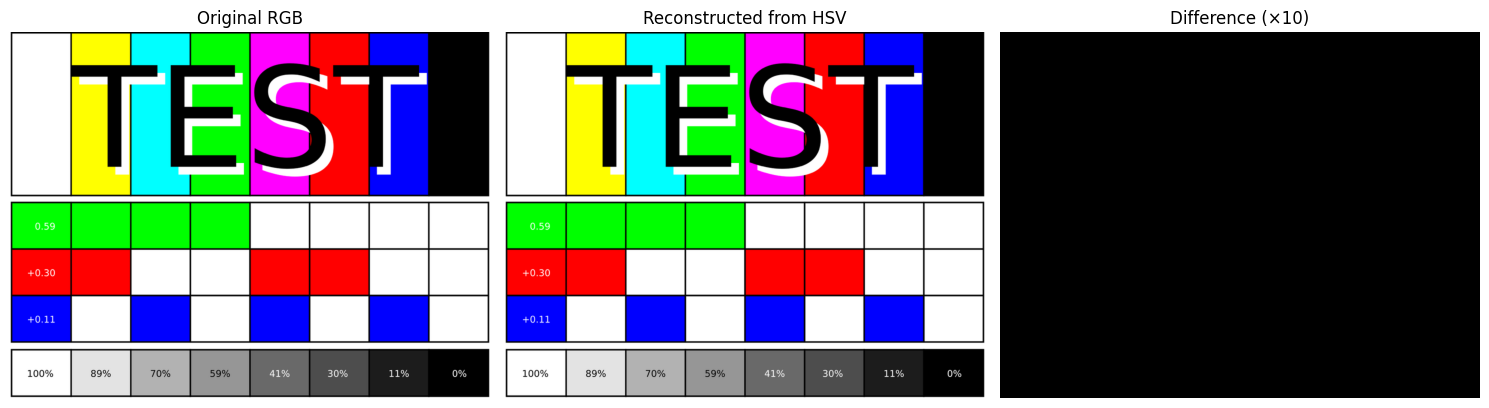

In [83]:
R, G, B = (R + m), (G + m), (B + m)
img_reconstructed_hsv = np.clip(np.stack([R, G, B], axis=2), 0, 1)

show_images(
    [img_norm, img_reconstructed_hsv, np.abs(img_norm - img_reconstructed_hsv) * 10],
    ['Original RGB', 'Reconstructed from HSV', 'Difference (×10)'],
    cmap_list=[None, None, 'hot']
)

The difference map being mostly black confirms the round-trip is mathematically clean. Any faint residual is floating-point rounding error from the division and modulo operations in the forward conversion.

### c. RGB -> YCbCr
YCbCr separates luminance from chrominance using a weighted matrix multiplication. The weights reflect human visual sensitivity: green contributes most to perceived brightness, blue the least. The standard used here is ITU-R BT.601, designed for standard-definition digital video.

`Step 1`: Scale the normalised RGB values back up to the digital 0–255 range. The BT.601 standard is defined in terms of these digital integer values rather than normalised floats.

In [84]:
R_d = img_norm[:,:,0] * 255
G_d = img_norm[:,:,1] * 255
B_d = img_norm[:,:,2] * 255

`Step 2`: Apply the BT.601 transformation. The +16 offset on Y reserves the lower digital range for synchronisation signals, placing pure black at Y=16 rather than 0. The +128 offset on Cb and Cr centres the chrominance values for unsigned 8-bit storage, so a neutral grey pixel produces Cb=Cr=128 exactly.

In [85]:
Y_manual  =  0.299  * R_d + 0.587  * G_d + 0.114  * B_d + 16
Cb_manual = -0.1687 * R_d - 0.3313 * G_d + 0.5000 * B_d + 128
Cr_manual =  0.5000 * R_d - 0.4187 * G_d - 0.0813 * B_d + 128

ycbcr_manual = np.stack([Y_manual, Cb_manual, Cr_manual], axis=2)

print(f"Y range:  {Y_manual.min():.1f} to {Y_manual.max():.1f}   (BT.601: 16 to 235)")
print(f"Cb range: {Cb_manual.min():.1f} to {Cb_manual.max():.1f}   (BT.601: 16 to 240)")
print(f"Cr range: {Cr_manual.min():.1f} to {Cr_manual.max():.1f}   (BT.601: 16 to 240)")

Y range:  16.0 to 271.0   (BT.601: 16 to 235)
Cb range: 0.5 to 255.5   (BT.601: 16 to 240)
Cr range: 0.5 to 255.5   (BT.601: 16 to 240)


Notice the Y channel does not reach 0 or 255, even pure black sits at 16 and pure white at 235. This is the BT.601 digital offset reserving headroom and footroom for broadcast signalling. The chrominance values are centred at 128, with values above indicating a blue or red bias and values below indicating the opposite.

### d. YCbCr -> RGB
The inverse applies the offsets in reverse before reconstructing the RGB matrix.

`Step 1`: Remove the digital offsets. Subtract 16 from Y to recover the black-level-corrected luminance, and subtract 128 from Cb and Cr to uncentre the chrominance values around zero.

In [86]:
Y_centred  = ycbcr_manual[:,:,0] - 16
Cb_centred = ycbcr_manual[:,:,1] - 128
Cr_centred = ycbcr_manual[:,:,2] - 128

print(f"Y centred range:  {Y_centred.min():.1f} to {Y_centred.max():.1f}")
print(f"Cb centred range: {Cb_centred.min():.1f} to {Cb_centred.max():.1f}")
print(f"Cr centred range: {Cr_centred.min():.1f} to {Cr_centred.max():.1f}")

Y centred range:  0.0 to 255.0
Cb centred range: -127.5 to 127.5
Cr centred range: -127.5 to 127.5


`Step 2`: Apply the inverse matrix coefficients. The constants 1.402, 0.344, 0.714, and 1.772 are derived from the original luminance weights, they are the values needed to invert the forward matrix correctly.

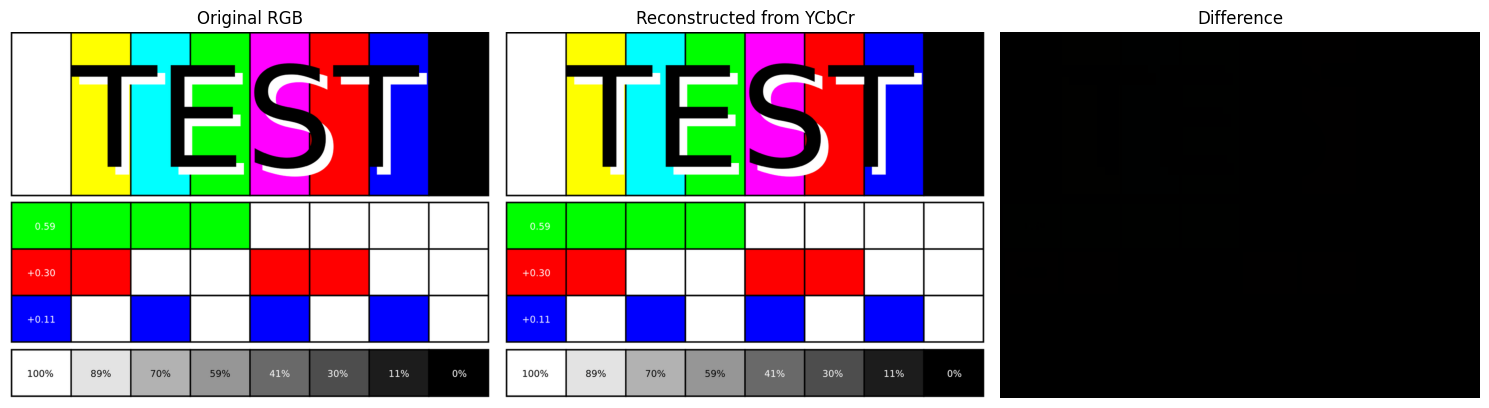

In [87]:
R = 1.000 * Y_centred + 1.402 * Cr_centred
G = 1.000 * Y_centred - 0.344 * Cb_centred - 0.714 * Cr_centred
B = 1.000 * Y_centred + 1.772 * Cb_centred

img_reconstructed_ycbcr = np.clip(np.stack([R, G, B], axis=2), 0, 255).astype(np.uint8)

show_images(
    [img_rgb, 
     img_reconstructed_ycbcr, 
     np.abs(img_rgb.astype(np.float32) - img_reconstructed_ycbcr.astype(np.float32)).astype(np.uint8)],
    ['Original RGB', 'Reconstructed from YCbCr', 'Difference'],
    cmap_list=[None, None, 'hot']
)

### e. RGB -> LAB
Converting to LAB requires two transformations: RGB → CIE XYZ → LAB. XYZ is a device-independent intermediate space that acts as a universal bridge. Skipping any step or using the wrong values produces silently incorrect results, particularly the first step, which is the most commonly forgotten.

`Step 1`: Digital RGB values are gamma-encoded for display, they are perceptually scaled rather than physically proportional to light. Before any colour mathematics can be applied correctly, this encoding must be removed. The piecewise function below handles the linear region near black separately from the power curve that dominates the rest of the range.

In [88]:
def linearise(c):
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

R_lin = linearise(img_norm[:,:,0])
G_lin = linearise(img_norm[:,:,1])
B_lin = linearise(img_norm[:,:,2])

print(f"Original R range: {img_norm[:,:,0].min():.3f} to {img_norm[:,:,0].max():.3f}")
print(f"Linearised R range: {R_lin.min():.3f} to {R_lin.max():.3f}")

Original R range: 0.000 to 1.000
Linearised R range: 0.000 to 1.000


`Step 2`: With linear light values, we apply the sRGB-to-XYZ transformation matrix. The XYZ coordinates correspond to how a standard human observer's three cone types respond to incoming light — making XYZ a device-independent description of colour that any display can be measured against.

In [89]:
X = 0.4124564*R_lin + 0.3575761*G_lin + 0.1804375*B_lin
Y = 0.2126729*R_lin + 0.7151522*G_lin + 0.0721750*B_lin
Z = 0.0193339*R_lin + 0.1191920*G_lin + 0.9503041*B_lin

print(f"X range: {X.min():.3f} to {X.max():.3f}")
print(f"Y range: {Y.min():.3f} to {Y.max():.3f}")
print(f"Z range: {Z.min():.3f} to {Z.max():.3f}")

X range: 0.000 to 0.950
Y range: 0.000 to 1.000
Z range: 0.000 to 1.089


`Step 3`: XYZ values are normalised against a reference white point — the colour that should appear as pure white. The D65 illuminant represents average midday daylight and is the standard for sRGB. Dividing by these values places pure white at (1, 1, 1) so the LAB calculation produces meaningful lightness coordinates.

In [90]:
X /= 0.95047
Y /= 1.00000
Z /= 1.08883

print(f"Normalised X range: {X.min():.3f} to {X.max():.3f}")
print(f"Normalised Y range: {Y.min():.3f} to {Y.max():.3f}")
print(f"Normalised Z range: {Z.min():.3f} to {Z.max():.3f}")

Normalised X range: 0.000 to 1.000
Normalised Y range: 0.000 to 1.000
Normalised Z range: 0.000 to 1.000


`Step 4`: The cube-root function models how humans perceive lightness non-linearly. Small changes in dark regions are far more noticeable than the same absolute change in bright regions. The piecewise threshold handles very dark values separately, where the cube root would be numerically unstable.

In [91]:
def f(t):
    return np.where(t > 0.008856, t ** (1/3), 7.787 * t + 16/116)

fx, fy, fz = f(X), f(Y), f(Z)

print(f"f(X) range: {fx.min():.3f} to {fx.max():.3f}")
print(f"f(Y) range: {fy.min():.3f} to {fy.max():.3f}")
print(f"f(Z) range: {fz.min():.3f} to {fz.max():.3f}")

f(X) range: 0.138 to 1.000
f(Y) range: 0.138 to 1.000
f(Z) range: 0.138 to 1.000


`Step 5`: The final LAB coordinates fall out as simple linear combinations. L* is derived from the Y axis (luminance), a* compares X-axis response to Y (green-to-red), and b* compares Y to Z (blue-to-yellow). The scaling factors (116, 500, 200) calibrate the output so that perceptual distances are roughly equal across the space.

In [92]:
L_manual = 116 * fy - 16
a_manual = 500 * (fx - fy)
b_manual = 200 * (fy - fz)

lab_manual = np.stack([L_manual, a_manual, b_manual], axis=2)

print(f"L* range: {L_manual.min():.2f} to {L_manual.max():.2f}")
print(f"a* range: {a_manual.min():.2f} to {a_manual.max():.2f}")
print(f"b* range: {b_manual.min():.2f} to {b_manual.max():.2f}")

L* range: 0.00 to 100.00
a* range: -86.18 to 98.23
b* range: -107.86 to 94.48


L* sits cleanly in the 0–100 range as designed. The a* and b* axes are centred at 0 with positive and negative values indicating direction along the green-red and blue-yellow axes respectively. A neutral grey pixel produces a* ≈ 0 and b* ≈ 0.

### f. LAB -> RGB
The inverse follows the pipeline in reverse. Each step undoes the corresponding forward step, ending with the gamma encoding that re-prepares the values for display.

`Step 1`: Unpack the LAB coordinates back into the intermediate f(x), f(y), f(z) values. The L* equation is rearranged for f(y) first, then f(x) and f(z) follow from a* and b* respectively.

In [93]:
L, a, b = lab_manual[:,:,0], lab_manual[:,:,1], lab_manual[:,:,2]

fy = (L + 16) / 116
fx = a / 500 + fy
fz = fy - b / 200

print(f"fx range: {fx.min():.3f} to {fx.max():.3f}")
print(f"fy range: {fy.min():.3f} to {fy.max():.3f}")
print(f"fz range: {fz.min():.3f} to {fz.max():.3f}")

fx range: 0.138 to 1.000
fy range: 0.138 to 1.000
fz range: 0.138 to 1.000


`Step 2`: Apply the inverse of the cube-root function — simply cubing each value. The piecewise threshold mirrors the forward function: values above 6/29 use the cube, below use the linear segment. Multiplying back by the D65 white point recovers the original XYZ tristimulus values.

In [94]:
def f_inv(t):
    return np.where(t > 0.206893, t**3, (t - 16/116) / 7.787)

X = 0.95047 * f_inv(fx)
Y = 1.00000 * f_inv(fy)
Z = 1.08883 * f_inv(fz)

print(f"Recovered X range: {X.min():.3f} to {X.max():.3f}")
print(f"Recovered Y range: {Y.min():.3f} to {Y.max():.3f}")
print(f"Recovered Z range: {Z.min():.3f} to {Z.max():.3f}")

Recovered X range: 0.000 to 0.950
Recovered Y range: 0.000 to 1.000
Recovered Z range: 0.000 to 1.089


`Step 3`: Apply the inverse of the sRGB-to-XYZ matrix to recover linear RGB values. Note that this matrix can produce slightly negative values for colours falling outside the sRGB gamut, colours that exist perceptually but cannot be physically displayed. These will be handled in the next step.

In [95]:
R_lin =  3.2404542*X - 1.5371385*Y - 0.4985314*Z
G_lin = -0.9692660*X + 1.8760108*Y + 0.0415560*Z
B_lin =  0.0556434*X - 0.2040259*Y + 1.0572252*Z

print(f"Linear R range: {R_lin.min():.3f} to {R_lin.max():.3f}")
print(f"Linear G range: {G_lin.min():.3f} to {G_lin.max():.3f}")
print(f"Linear B range: {B_lin.min():.3f} to {B_lin.max():.3f}")

Linear R range: -0.000 to 1.000
Linear G range: -0.000 to 1.000
Linear B range: -0.000 to 1.000


`Step 4`: Re-apply the gamma encoding that was removed at the start of the forward conversion. Negative linear RGB values are clipped to zero before applying the power function, since fractional powers of negative numbers are mathematically undefined. The output is then clipped to [0, 1] for display.

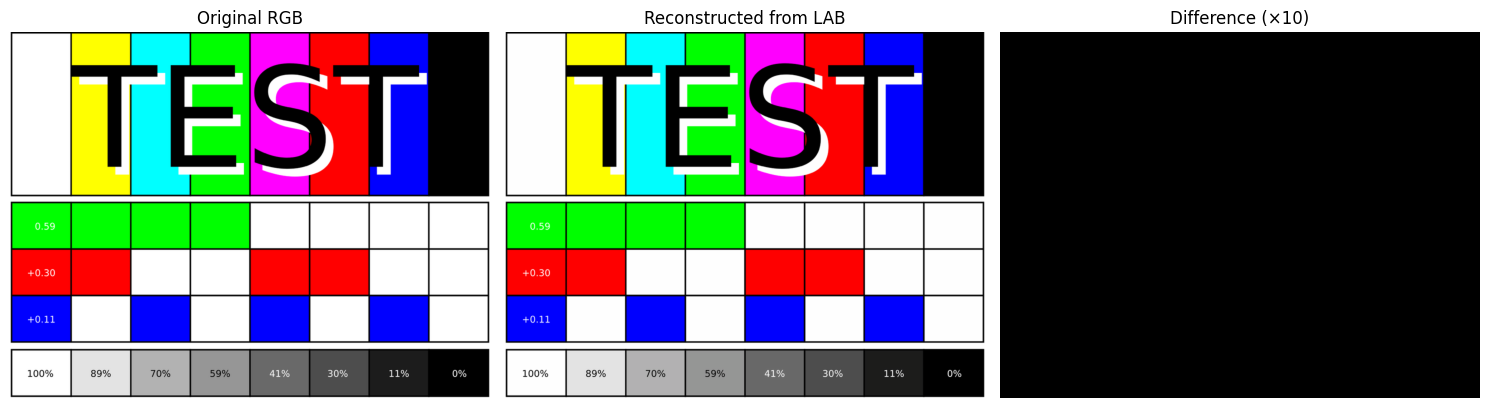

In [96]:
def gamma(c):
    c_safe = np.clip(c, 0, None)
    return np.where(c > 0.0031308,
                    1.055 * (c_safe ** (1/2.4)) - 0.055,
                    12.92 * c)

R, G, B = gamma(R_lin), gamma(G_lin), gamma(B_lin)
img_reconstructed_lab = np.clip(np.stack([R, G, B], axis=2), 0, 1)

show_images(
    [img_norm, img_reconstructed_lab, np.abs(img_norm - img_reconstructed_lab) * 10],
    ['Original RGB', 'Reconstructed from LAB', 'Difference (×10)'],
    cmap_list=[None, None, 'hot']
)

The difference map confirms the LAB pipeline is invertible within floating-point precision. This is the most computationally expensive of the three conversions (five steps in each direction) but the round-trip remains clean because every step has a well-defined inverse.

## What happens when conversions are done incorrectly?
Here we deliberately introduce the most common conversion errors to show their visual effect.

The conversions above were broken down step by step to make the mathematics visible. Below they are wrapped as reusable functions so the error demonstrations that follow can call them directly without repeating the entire pipeline each time.

In [97]:
# RGB to HSV
def rgb_to_hsv_manual(img_norm):
    R, G, B = img_norm[:,:,0], img_norm[:,:,1], img_norm[:,:,2]
    V = np.max(img_norm, axis=2)
    m = np.min(img_norm, axis=2)
    delta = V - m
    
    V_safe = np.where(V == 0, 1, V)
    S = np.where(V == 0, 0, delta / V_safe)
    
    H = np.zeros_like(V)
    delta_safe = np.where(delta == 0, 1, delta)
    mask_r = (V == R) & (delta != 0)
    mask_g = (V == G) & (delta != 0)
    mask_b = (V == B) & (delta != 0)
    H[mask_r] = 60 * (((G - B) / delta_safe) % 6)[mask_r]
    H[mask_g] = 60 * (((B - R) / delta_safe) + 2)[mask_g]
    H[mask_b] = 60 * (((R - G) / delta_safe) + 4)[mask_b]
    H[delta == 0] = 0
    
    return np.stack([H, S, V], axis=2)

# HSV to RGB
def hsv_to_rgb_manual(hsv):
    H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    C = V * S
    X = C * (1 - np.abs((H / 60) % 2 - 1))
    m = V - C
    
    R, G, B = np.zeros_like(H), np.zeros_like(H), np.zeros_like(H)
    masks = [
        (H < 60), (H >= 60) & (H < 120), (H >= 120) & (H < 180),
        (H >= 180) & (H < 240), (H >= 240) & (H < 300), (H >= 300) & (H < 360)
    ]
    rgb_vals = [
        (C, X, 0), (X, C, 0), (0, C, X),
        (0, X, C), (X, 0, C), (C, 0, X)
    ]
    for mask, (r, g, b) in zip(masks, rgb_vals):
        R[mask] = r if np.isscalar(r) else r[mask]
        G[mask] = g if np.isscalar(g) else g[mask]
        B[mask] = b if np.isscalar(b) else b[mask]
    
    R, G, B = (R + m), (G + m), (B + m)
    return np.clip(np.stack([R, G, B], axis=2), 0, 1)

# RGB to YCbCr using BT.601 standard
def rgb_to_ycbcr_manual(img_rgb_uint8):
    img = img_rgb_uint8.astype(np.float32)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    Y  =  0.299  * R + 0.587  * G + 0.114  * B + 16
    Cb = -0.1687 * R - 0.3313 * G + 0.5000 * B + 128
    Cr =  0.5000 * R - 0.4187 * G - 0.0813 * B + 128
    return np.stack([Y, Cb, Cr], axis=2)

# YCbCr to RGB using BT.601 standard
def ycbcr_to_rgb_manual(ycbcr):
    Y  = ycbcr[:,:,0]
    Cb = ycbcr[:,:,1]
    Cr = ycbcr[:,:,2]
    R = 1.000 * (Y - 16) + 1.402 * (Cr - 128)
    G = 1.000 * (Y - 16) - 0.344 * (Cb - 128) - 0.714 * (Cr - 128)
    B = 1.000 * (Y - 16) + 1.772 * (Cb - 128)
    return np.clip(np.stack([R, G, B], axis=2), 0, 255).astype(np.uint8)

def rgb_to_lab_manual(img_norm):
    def linearise(c):
        return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)
    R = linearise(img_norm[:,:,0])
    G = linearise(img_norm[:,:,1])
    B = linearise(img_norm[:,:,2])
    X = 0.4124564*R + 0.3575761*G + 0.1804375*B
    Y = 0.2126729*R + 0.7151522*G + 0.0721750*B
    Z = 0.0193339*R + 0.1191920*G + 0.9503041*B
    X /= 0.95047; Y /= 1.00000; Z /= 1.08883
    def f(t):
        return np.where(t > 0.008856, t**(1/3), 7.787*t + 16/116)
    L = 116 * f(Y) - 16
    a = 500 * (f(X) - f(Y))
    b = 200 * (f(Y) - f(Z))
    return np.stack([L, a, b], axis=2)


print("Functions defined: rgb_to_hsv_manual, hsv_to_rgb_manual, rgb_to_ycbcr_manual, ycbcr_to_rgb_manual, rgb_to_lab_manual")

Functions defined: rgb_to_hsv_manual, hsv_to_rgb_manual, rgb_to_ycbcr_manual, ycbcr_to_rgb_manual, rgb_to_lab_manual


### a. OpenCV Hue range (0-180 vs 0-360)
OpenCV stores H in 0–180 to fit in a uint8, so if you take a raw OpenCV HSV output and treat it as 0–360 degrees in your own calculations, every hue-based operation will be wrong.

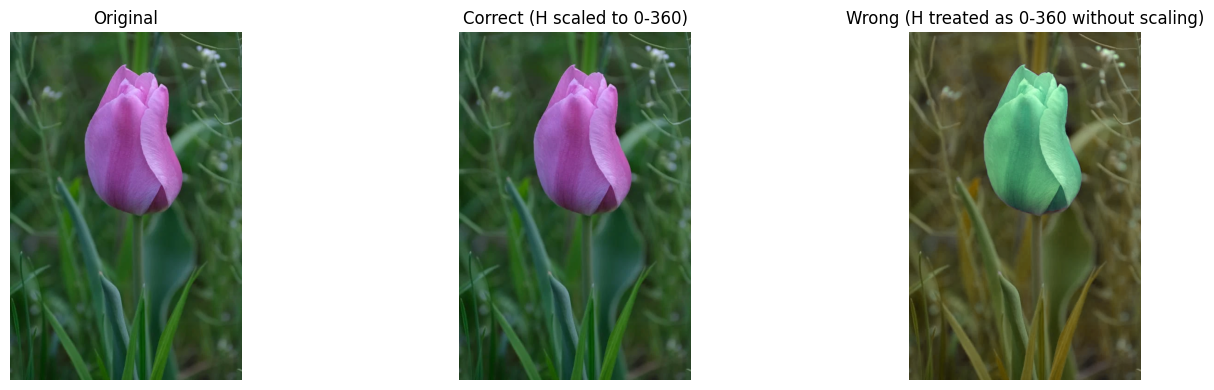

In [98]:
# Take OpenCV HSV output and mistakenly treat H as 0-360
img_hsv_cv = cv2.cvtColor(img_tulip_rgb, cv2.COLOR_RGB2HSV)

# Correct: scale H back to 0-360 before converting
hsv_correct = img_hsv_cv.astype(np.float32)
hsv_correct[:,:,0] *= 2  # 0-180 -> 0-360
hsv_correct[:,:,1] /= 255
hsv_correct[:,:,2] /= 255
reconstructed_correct = hsv_to_rgb_manual(hsv_correct)

# Wrong: treat H as already being 0-360 (it isn't)
hsv_wrong = img_hsv_cv.astype(np.float32)
hsv_wrong[:,:,1] /= 255
hsv_wrong[:,:,2] /= 255
reconstructed_wrong = hsv_to_rgb_manual(hsv_wrong)

show_images(
    [img_tulip_rgb, reconstructed_correct, reconstructed_wrong],
    ['Original', 'Correct (H scaled to 0-360)', 'Wrong (H treated as 0-360 without scaling)']
)

### b. Not normalising before RGB -> HSV
The manual function expects float input in [0,1]. If a raw uint8 image (0–255) is passed without normalising first, the max/min/delta calculations produce completely wrong V values since it is simply the max channel intensity with no normalisation. Hue and Saturation are not affected because both are calculated from ratios where the scale cancels out.

In [99]:
# Correct: normalised input
hsv_correct = rgb_to_hsv_manual(img_norm)

# Wrong: passing uint8 directly without normalising
hsv_wrong = rgb_to_hsv_manual(img_rgb.astype(np.float32))  # values 0-255 not 0-1

print("Correct V range:", hsv_correct[:,:,2].min(), "to", hsv_correct[:,:,2].max())
print("Wrong V range:  ", hsv_wrong[:,:,2].min(), "to", hsv_wrong[:,:,2].max())
print("Correct S range:", hsv_correct[:,:,1].min(), "to", hsv_correct[:,:,1].max())
print("Wrong S range:  ", hsv_wrong[:,:,1].min(), "to", hsv_wrong[:,:,1].max())

Correct V range: 0.0 to 1.0
Wrong V range:   0.0 to 255.0
Correct S range: 0.0 to 1.0
Wrong S range:   0.0 to 1.0


### c. Skipping gamma linearisation before LAB
Skipping the linearisation step and passing gamma-encoded RGB values directly into the XYZ matrix treats non-linear display values as if they were physical light measurements, producing incorrect XYZ tristimulus values and ultimately a compressed, inaccurate L channel.

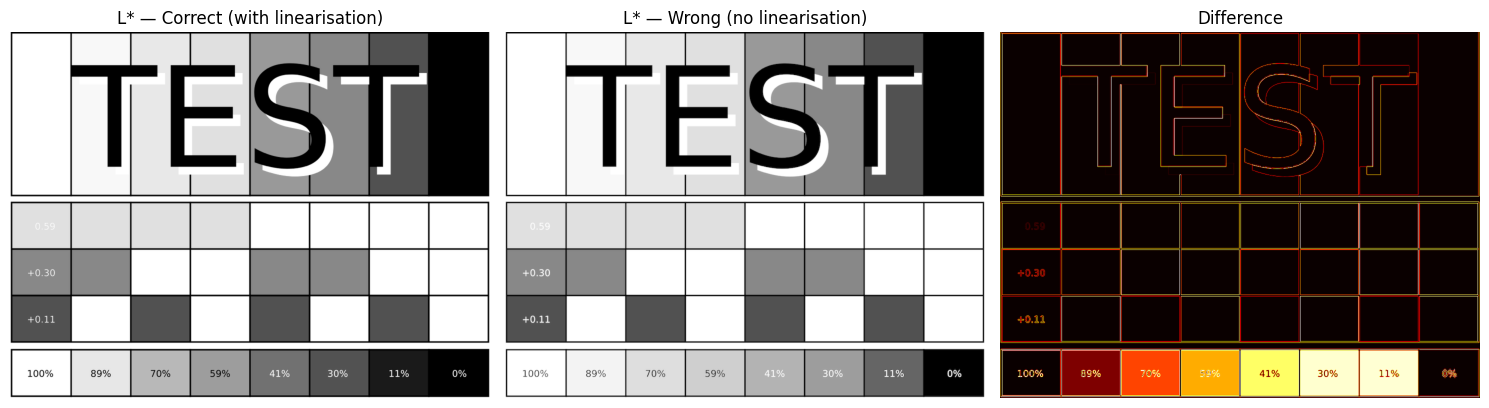

L* difference max: 30.61457


In [100]:
def rgb_to_lab_no_linearise(img_norm):
    # Skip linearisation — use raw normalised values directly
    R, G, B = img_norm[:,:,0], img_norm[:,:,1], img_norm[:,:,2]

    # Use the same RGB->XYZ matrix but on non-linearised RGB
    X = 0.4124564*R + 0.3575761*G + 0.1804375*B
    Y = 0.2126729*R + 0.7151522*G + 0.0721750*B
    Z = 0.0193339*R + 0.1191920*G + 0.9503041*B

    X /= 0.95047; Y /= 1.00000; Z /= 1.08883

    def f(t):
        return np.where(t > 0.008856, t**(1/3), 7.787*t + 16/116)

    L = 116 * f(Y) - 16
    a = 500 * (f(X) - f(Y))
    b = 200 * (f(Y) - f(Z))

    return np.stack([L, a, b], axis=2)

lab_wrong = rgb_to_lab_no_linearise(img_norm)

show_images(
    [lab_manual[:,:,0], lab_wrong[:,:,0], np.abs(lab_manual[:,:,0] - lab_wrong[:,:,0])],
    ['L* — Correct (with linearisation)', 'L* — Wrong (no linearisation)', 'Difference'],
    cmap_list=['gray', 'gray', 'hot']
)

print("L* difference max:", np.abs(lab_manual[:,:,0] - lab_wrong[:,:,0]).max())

### d. Using the wrong BT standard (BT.601 encode, BT.709 decode)
Encoding with BT.601 but decoding with BT.709 introduces a visible colour cast across the entire image, because the two standards use different luminance weights derived from different display primaries. The coefficients are not interchangeable even though the equation structure looks identical.

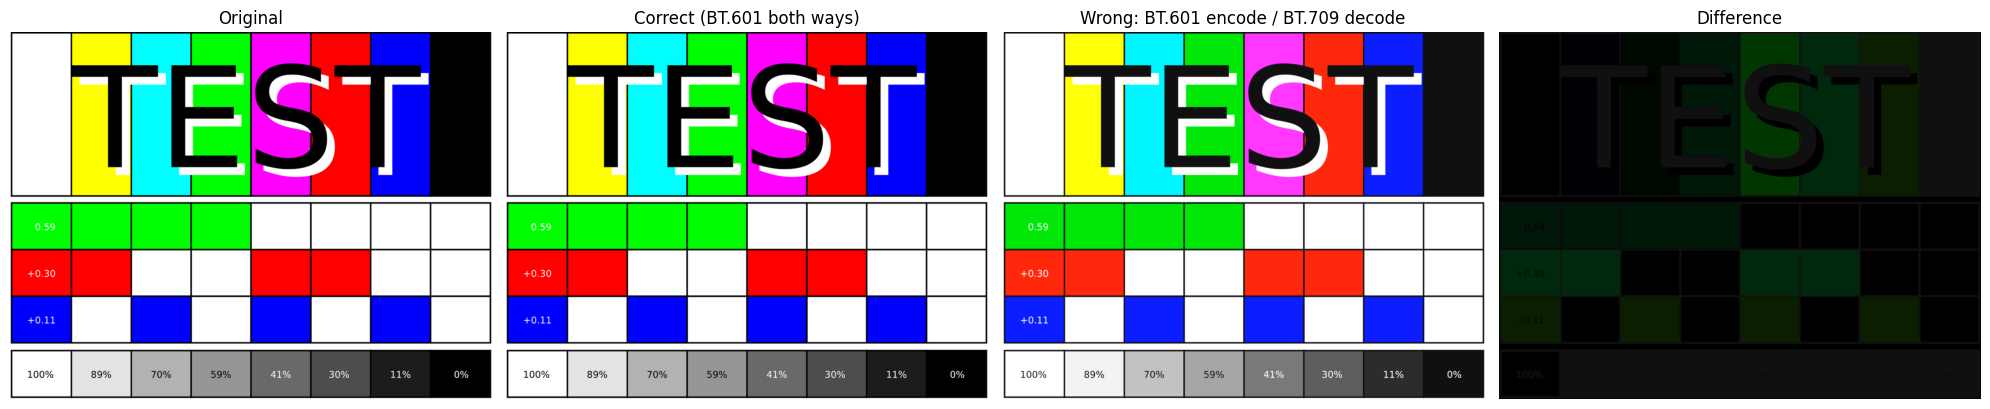

In [101]:
# BT.709 decode coefficients (different from BT.601)
def ycbcr_to_rgb_bt709(ycbcr):
    Y  = ycbcr[:,:,0]
    Cb = ycbcr[:,:,1]
    Cr = ycbcr[:,:,2]

    R = Y + 1.5748 * (Cr - 128)
    G = Y - 0.1873 * (Cb - 128) - 0.4681 * (Cr - 128)
    B = Y + 1.8556 * (Cb - 128)

    return np.clip(np.stack([R, G, B], axis=2), 0, 255).astype(np.uint8)

# Encoded with BT.601 but decoded with BT.709
wrong_standard = ycbcr_to_rgb_bt709(ycbcr_manual)

show_images(
    [img_rgb, img_reconstructed_ycbcr, wrong_standard, np.abs(img_rgb.astype(np.float32) - wrong_standard.astype(np.float32)).astype(np.uint8)],
    ['Original', 'Correct (BT.601 both ways)', 'Wrong: BT.601 encode / BT.709 decode', 'Difference']
)

# Summary

This notebook walked through four colour spaces; RGB, HSV, YCbCr, and LAB, and the conversion equations that connect them. Each space was implemented manually in NumPy to make the underlying mathematics visible, and each conversion was verified against its inverse using a difference map.

| Conversion | Key step | Common error |
|---|---|---|
| RGB → HSV | Piecewise hue from dominant channel | Undefined hue at S=0 |
| HSV → RGB | Sector lookup + match offset | Wrong hue range (OpenCV 0–180 vs 0–360) |
| RGB → YCbCr | Weighted matrix + digital offsets | Mixing BT.601 and BT.709 standards |
| YCbCr → RGB | Remove offsets then invert matrix | Forgetting Y offset of 16 |
| RGB → LAB | Linearise → XYZ → f(t) → LAB | Skipping gamma linearisation |
| LAB → RGB | Reverse f(t) → XYZ → gamma | Negative values before power function |

RGB acts as the hub for all conversions — there are no direct formulas between HSV, YCbCr, and LAB. Every cross-space conversion routes through RGB as an intermediate step.